<a href="https://colab.research.google.com/github/Girisha-Malni-builds01/AI-Placement-Practice-Notebook/blob/Deep-Learning-Basic-Algorithms/FNN%20%26%20RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FeedForward Neural Network**

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt

**1. Define FNN Model**

In [3]:
class FNN(nn.Module):
    def __init__(self):
        super(FNN, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)   # flatten image
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        return out

model = FNN()

**2. Training on MNIST**

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1000, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Training FNN on MNIST...")
for epoch in range(3):  # train for 3 epochs
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch [{epoch+1}/3], Loss: {loss.item():.4f}")

# Save trained model
torch.save(model.state_dict(), "fnn_mnist.pth")

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.20MB/s]


Training FNN on MNIST...
Epoch [1/3], Loss: 0.1296
Epoch [2/3], Loss: 0.0311
Epoch [3/3], Loss: 0.0942


**3. Predict Uploaded Image**

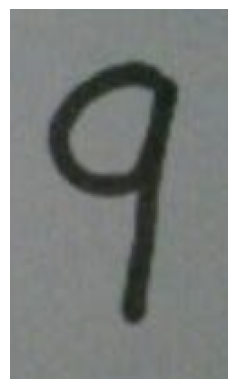

Predicted Digit: 1


In [10]:
model.load_state_dict(torch.load("fnn_mnist.pth"))
model.eval()

# Define transform for uploaded image
custom_transform = transforms.Compose([
    transforms.Grayscale(),        # ensure single channel
    transforms.Resize((28, 28)),   # resize to MNIST size
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

def predict_image(image_path):
    img = Image.open(image_path)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.show()

    img = custom_transform(img).unsqueeze(0)  # preprocess + batch dim
    with torch.no_grad():
        output = model(img)
        _, predicted = torch.max(output, 1)
    print(f"Predicted Digit: {predicted.item()}")

predict_image("/content/Screenshot 2025-09-11 at 9.06.00 PM.png")

# **MNIST Digit Recognition with RNN**

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

**1. Hyperparameters**

In [22]:
input_size = 28      # each row has 28 pixels
sequence_length = 28 # 28 rows
hidden_size = 128
num_layers = 2
num_classes = 10
batch_size = 64
learning_rate = 0.001
num_epochs = 15

**2. Dataset**

In [23]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1000, shuffle=False)

**3. Define RNN Model**

In [24]:
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch, 1, 28, 28)
        x = x.squeeze(1)          # (batch, 28, 28)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)  # initial hidden state
        out, _ = self.rnn(x, h0)  # out: (batch, seq_len, hidden_size)
        out = out[:, -1, :]       # take last time step
        out = self.fc(out)
        return out

model = RNNModel(input_size, hidden_size, num_layers, num_classes)


**4. Loss & Optimizer**

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

**5. Training**

In [26]:
print("Training RNN on MNIST...")
for epoch in range(num_epochs):
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Training RNN on MNIST...
Epoch [1/15], Loss: 0.4669
Epoch [2/15], Loss: 0.1967
Epoch [3/15], Loss: 0.0917
Epoch [4/15], Loss: 0.0462
Epoch [5/15], Loss: 0.2442
Epoch [6/15], Loss: 0.0291
Epoch [7/15], Loss: 0.0220
Epoch [8/15], Loss: 0.2395
Epoch [9/15], Loss: 0.0244
Epoch [10/15], Loss: 0.0645
Epoch [11/15], Loss: 0.1803
Epoch [12/15], Loss: 0.2228
Epoch [13/15], Loss: 0.1772
Epoch [14/15], Loss: 0.2234
Epoch [15/15], Loss: 0.1667


In [27]:
# Save model
torch.save(model.state_dict(), "rnn_mnist.pth")

**6. Testing**

In [28]:
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 96.94%


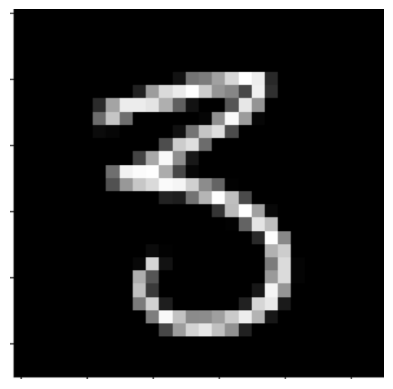

Predicted Digit: 3


In [33]:
model.load_state_dict(torch.load("rnn_mnist.pth"))
model.eval()

# Transform for uploaded image
custom_transform = transforms.Compose([
    transforms.Grayscale(),        # ensure 1 channel
    transforms.Resize((28, 28)),   # MNIST size
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

def predict_image(image_path):
    img = Image.open(image_path)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.show()

    img = custom_transform(img).unsqueeze(0)  # add batch dim
    with torch.no_grad():
        output = model(img)
        _, predicted = torch.max(output, 1)
    print(f"Predicted Digit: {predicted.item()}")

predict_image("/content/Screenshot 2025-09-11 at 9.04.09 PM.png")